In [1]:
import numpy as np
import scipy.signal
import scipy.linalg
import cvxpy as cp
import matplotlib.pyplot as plt

In [ ]:
m_B = 51.66 # mass of robot body (kg)
m_b = 2.44 # mass of ball (kg)
l = 0.69 # distance from ball center to body COM (m) # 
I_b = 0.0174 # ball moment of inertia (kg-m^2)
r_b = 0.1058 # ball radius (m)
I_B = 12.59 # inertia of body about its own COM (kg-m^2), Nagarajan 2013 Table 1
mu_theta = 3.68 # theta viscous damping coefficient (N-m-s/rad)
mu_phi = 3.68 # phi viscous damping coefficient (N-m-s/rad)
dt = 0.1
g = 9.81
ki = 1
kp = 0.5

Gamma_1 = I_b + I_B + m_b * r_b**2 + m_B * r_b**2 + m_B * l**2
Gamma_2 = I_B + m_B * l**2

M_star = np.array([
    [Gamma_1 + 2 * m_B * r_b * l, Gamma_2 + m_B * r_b * l],
    [Gamma_2 + m_B * r_b * l, Gamma_2]
])

# Compute the inverse of the mass matrix
M_star_inv = np.linalg.inv(M_star)

matrix_to_multiply = np.array([
    [m_B * g * l, m_B * g * l, -mu_theta, 0, 0],
    [m_B * g * l - ki, m_B * g * l, -kp, -mu_phi, ki]
])

# Compute the resulting matrix
result_matrix = np.dot(M_star_inv, matrix_to_multiply)
result_matrix_2 = np.dot(M_star_inv, np.array([0, kp]))

# Construct the final A matrix
A = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [result_matrix[0, 0], result_matrix[0, 1], result_matrix[0, 2], result_matrix[0, 3], result_matrix[0, 4]],
    [result_matrix[1, 0], result_matrix[1, 1], result_matrix[1, 2], result_matrix[1, 3], result_matrix[1, 4]],
    [0, 0, 0, 0, 0]
])

# Define the B matrix
B = np.array([
    [0],
    [0],
    [result_matrix_2[0]],
    [result_matrix_2[1]],
    [1]
])

sys_cont = scipy.signal.StateSpace(A, B, np.eye(5), np.zeros((5, 1)))
sys_disc = sys_cont.to_discrete(dt)
A_d = sys_disc.A
B_d = sys_disc.B

# Sanity checks before any control design
print('M_star eigenvalues (must both be > 0):', np.linalg.eigvals(M_star))
print('Continuous eig(A) (expect one positive = body falling):', np.round(np.linalg.eigvals(A), 3))
ctrb = np.hstack([np.linalg.matrix_power(A, i) @ B for i in range(5)])
print('Controllability rank (expect 5):', np.linalg.matrix_rank(ctrb))

M_star eigenvalues (must both be > 0): [82.42769967  0.1084949 ]
Continuous eig(A) (expect one positive = body falling): [-32.265   3.133  -2.686   0.144   0.   ]
Controllability rank (expect 5): 5


In [3]:
T = 700  # time steps
n = 5   # state dimension
m = 1   # control dimension
MPC = 20 # MPC time horizon

Q = np.diag([1, 1, 1, 1, 0])
R = np.array([[15]])

Initial_tilt = 0 # insert in degrees
IT_R = Initial_tilt * np.pi/180 # conversion to rad

Initial_velocity = 0 # insert in deg/s
IV_R = Initial_velocity * np.pi/180 #convert to rad/s

Initial_displacement = 1 # insert in m
ID_R = Initial_displacement / r_b # convert to rad

limit = 5 * np.pi/180 # angle limit
speed_limit = 0.04 / r_b

initial_state = np.array([ID_R, IT_R - ID_R, 0.0, IV_R, 0])
state = initial_state
goal_state = np.zeros(5)

# LQR baseline and MPC terminal cost from the discrete Riccati equation.
P = scipy.linalg.solve_discrete_are(A_d, B_d, Q, R)
K = np.linalg.solve(R + B_d.T @ P @ B_d, B_d.T @ P @ A_d)
print('LQR gain K:', np.round(K, 3))

# LQR Simulation to use as a comparison for our MPC controller implementation
def simulate_lqr(K, initial_state, T):
    # u = -K x applied to the discrete model for T steps
    state = initial_state.copy()
    states = np.zeros((T+1, n))
    controls = np.zeros((T, m))
    states[0] = state
    for k in range(T):
        u = -K @ state
        controls[k] = u
        state = A_d @ state + B_d @ u
        states[k+1] = state
    return states, controls

def motor_torque(states, controls):
    # inner PI loop torque: tau = kp (omega_d - theta_dot) + ki (x5 - theta)   (Lauwers 2005 p.7)
    return kp * (controls[:, 0] - states[:-1, 2]) + ki * (states[:-1, 4] - states[:-1, 0])

LQR gain K: [[410.259 412.044 134.594 123.032   2.044]]


In [4]:
def build_mpc(speed_limit=None, lean_limit=None, torque_limit=None, rho=1e4):
    x_init = cp.Parameter(n)                    # measured state, set every MPC step
    xs = cp.Variable((MPC+1, n))
    us = cp.Variable((MPC, m))
    slack = cp.Variable((MPC, 3), nonneg=True)

    objective = 0
    constraints = [xs[0] == x_init]

    for t in range(MPC):
        objective += (cp.quad_form(xs[t], Q) + cp.quad_form(us[t], R))
        objective += rho * cp.sum(slack[t]) + rho * cp.sum_squares(slack[t])
        constraints += [xs[t+1] == A_d @ xs[t] + B_d @ us[t]]

        # Speed Limit Constraint
        if speed_limit is not None:
            constraints += [xs[t+1, 2] / speed_limit <= 1 + slack[t, 0], xs[t+1, 2] / speed_limit >= -1 - slack[t, 0]]

        # Lean Limit Constraint
        if lean_limit is not None:
            lean = xs[t+1, 0] + xs[t+1, 1]
            constraints += [lean / lean_limit <= 1 + slack[t, 1], lean / lean_limit >= -1 - slack[t, 1]]

        # Torque Limit Constraint
        if torque_limit is not None:
            tau = kp * (us[t, 0] - xs[t, 2]) + ki * (xs[t, 4] - xs[t, 0])
            constraints += [tau / torque_limit <= 1 + slack[t, 2], tau / torque_limit >= -1 - slack[t, 2]]

    objective += cp.quad_form(xs[MPC] - goal_state, P)

    problem = cp.Problem(cp.Minimize(objective), constraints)
    return problem, x_init, us, slack

def run_mpc(initial_state, T, speed_limit=None, lean_limit=None, torque_limit=None):
    problem, x_init, us, slack = build_mpc(speed_limit, lean_limit, torque_limit)
    state = initial_state.copy()
    states = np.zeros((T+1, n))
    controls = np.zeros((T, m))
    states[0] = state
    max_slack = 0

    # MPC Loop
    for k in range(T):
        x_init.value = state
        problem.solve(solver=cp.CLARABEL)
        if problem.status not in ['optimal', 'optimal_inaccurate']:
            raise RuntimeError(f'MPC solve failed at step {k}: {problem.status}')
        max_slack = max(max_slack, slack.value.max())

        u = us.value[0]
        controls[k] = u

        state = A_d @ state + B_d @ u
        states[k+1] = state

    return states, controls, max_slack

# Main run: 1 m move with the speed limit
states, controls, max_slack = run_mpc(initial_state, T, speed_limit=speed_limit)
states_lqr, controls_lqr = simulate_lqr(K, initial_state, T)
print('Largest planned violation (fraction of limit):', max_slack)
print('Realized peak speed (m/s): %.4f | limit %.4f' % (np.max(np.abs(states[:, 2])) * r_b, speed_limit * r_b))

linear_position = states[:,0] * r_b
linear_position_lqr = states_lqr[:,0] * r_b
ball_speed = states[:,2] * r_b
ball_speed_lqr = states_lqr[:,2] * r_b

states = states * 180 / np.pi
states_lqr = states_lqr * 180 / np.pi

test = np.sin(np.deg2rad(states[:,0] + states[:,1]))
test2 = states[:,1] + states [:,0]
test2_lqr = states_lqr[:,1] + states_lqr[:,0]

Largest planned violation (fraction of limit): 0.0026221785898361064
Realized peak speed (m/s): 0.0401 | limit 0.0400


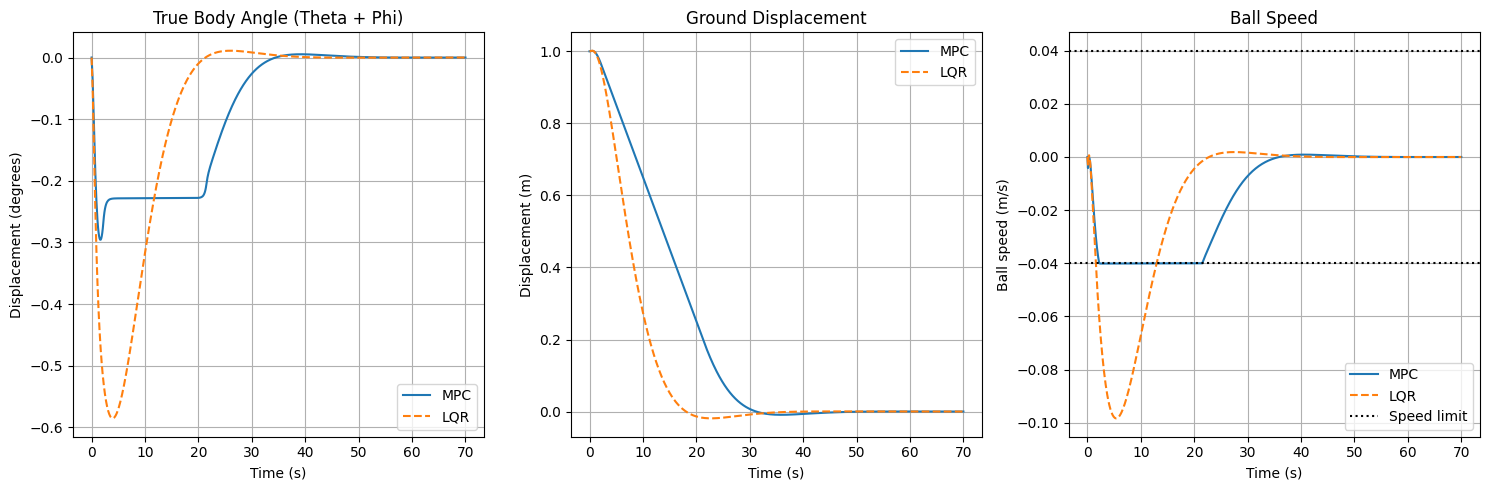

In [5]:
Time = np.linspace(0, T*dt, T+1)

# Plot the states
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
#plt.plot(Time, test, label = 'Sin(Theta + Phi)')
plt.plot(Time, test2, label = 'MPC') 
plt.plot(Time, test2_lqr, '--', label = 'LQR')
#plt.plot(Time, states[:, 0], label='Ball Displacement')
#plt.plot(Time, states[:, 1], label='Body Angle')
#plt.plot(states[:, 2], label='Theta_D')
#plt.plot(states[:, 3], label='Phi_D')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (degrees)')
plt.legend()
plt.title('True Body Angle (Theta + Phi)')
plt.grid()

# Plot the ground displacement
plt.subplot(1, 3, 2)
plt.plot(Time, linear_position, label = 'MPC')
plt.plot(Time, linear_position_lqr, '--', label = 'LQR')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Ground Displacement')
plt.legend()
plt.grid()

# Plot the constrained quantity against its limit
plt.subplot(1, 3, 3)
plt.plot(Time, ball_speed, label = 'MPC')
plt.plot(Time, ball_speed_lqr, '--', label = 'LQR')
plt.axhline(-speed_limit * r_b, color = 'k', linestyle = ':', label = 'Speed limit')
plt.axhline(speed_limit * r_b, color = 'k', linestyle = ':')
plt.xlabel('Time (s)')
plt.ylabel('Ball speed (m/s)')
plt.title('Ball Speed')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Experiment 1: Giving the MPC controller a situation in which the constraints never trigger, caused by the ballbot never hitting the speed limit. Therefore, it's essentially just following the LQR solution.

In [6]:
small_state = np.array([0.25 / r_b, -0.25 / r_b, 0.0, 0.0, 0])
X_mpc, U_mpc, _ = run_mpc(small_state, 300, speed_limit=speed_limit)
X_lqr, U_lqr = simulate_lqr(K, small_state, 300)

print('Peak LQR speed (m/s):', np.max(np.abs(X_lqr[:, 2])) * r_b, ' limit:', speed_limit * r_b)
print('Max |x_mpc - x_lqr| (rad):', np.max(np.abs(X_mpc - X_lqr)))
print('Max |u_mpc - u_lqr| (rad/s):', np.max(np.abs(U_mpc - U_lqr)))

Peak LQR speed (m/s): 0.024590898016998337  limit: 0.04
Max |x_mpc - x_lqr| (rad): 2.627937867316632e-09
Max |u_mpc - u_lqr| (rad/s): 3.92533278104068e-09


Experiment 2: Detuning the LQR matrix to show why you can't just tune the R matrix to enact an explicit constraint with the performance and success of MPC.

Detuned R: 384.43359375
move (m) |   LQR v    t_s | detuned v    t_s |   MPC v    t_s
    0.10 |   0.010   16.6 |     0.004   60.0 |   0.010   16.6
    0.25 |   0.025   16.6 |     0.010   60.0 |   0.025   16.6
    0.50 |   0.049   16.6 |     0.019   60.0 |   0.040   17.6
    1.00 |   0.098   16.6 |     0.038   60.0 |   0.040   28.6
    2.00 |   0.197   16.6 |     0.076   60.0 |   0.040   51.9


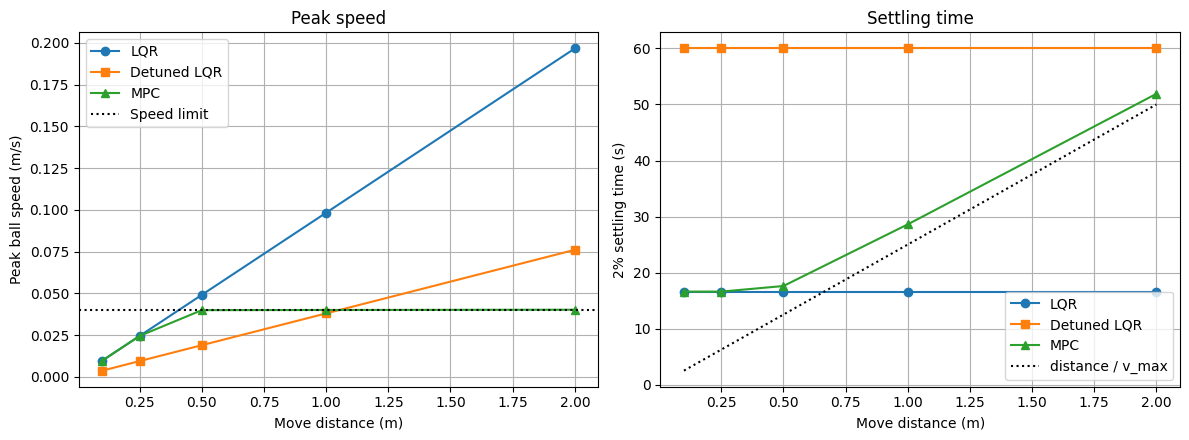

In [ ]:
def settling_time(states, distance):
    position = states[:, 0] * r_b
    outside = np.where(np.abs(position) > 0.02 * distance)[0]
    return (outside[-1] + 1) * dt if len(outside) > 0 else 0.0

# Search for the smallest R (x1.5 steps) that keeps the 1 m LQR move under the speed limit
R_detuned = R.astype(float)
while True:
    P_det = scipy.linalg.solve_discrete_are(A_d, B_d, Q, R_detuned)
    K_detuned = np.linalg.solve(R_detuned + B_d.T @ P_det @ B_d, B_d.T @ P_det @ A_d)
    X_det, _ = simulate_lqr(K_detuned, initial_state, 1500)
    if np.max(np.abs(X_det[:, 2])) <= speed_limit:
        break
    R_detuned = R_detuned * 1.5
print('Detuned R:', R_detuned[0, 0])

distances = [0.1, 0.25, 0.5, 1.0, 2.0]
T_sweep = 1500
results = []
for d in distances:
    x0 = np.array([d / r_b, -d / r_b, 0.0, 0.0, 0])
    X_l, _ = simulate_lqr(K, x0, T_sweep)
    X_dl, _ = simulate_lqr(K_detuned, x0, T_sweep)
    X_m, _, _ = run_mpc(x0, T_sweep, speed_limit=speed_limit)
    results.append([d,
                    np.max(np.abs(X_l[:, 2])) * r_b, settling_time(X_l, d),
                    np.max(np.abs(X_dl[:, 2])) * r_b, settling_time(X_dl, d),
                    np.max(np.abs(X_m[:, 2])) * r_b, settling_time(X_m, d)])
results = np.array(results)

print(f"{'move (m)':>8} | {'LQR v':>7} {'t_s':>6} | {'detuned v':>9} {'t_s':>6} | {'MPC v':>7} {'t_s':>6}")
for row in results:
    print(f'{row[0]:8.2f} | {row[1]:7.3} {row[2]:6.1f} | {row[3]:9.3f} {row[4]:6.1f} | {row[5]:7.3f} {row[6]:6.1f}')

plt.figure(figsize=(12, 4.5))
plt.subplot(1, 2, 1)
plt.plot(results[:, 0], results[:, 1], 'o-', label = 'LQR')
plt.plot(results[:, 0], results[:, 3], 's-', label = 'Detuned LQR')
plt.plot(results[:, 0], results[:, 5], '^-', label = 'MPC')
plt.axhline(speed_limit * r_b, color = 'k', linestyle = ':', label = 'Speed limit')
plt.xlabel('Move distance (m)')
plt.ylabel('Peak ball speed (m/s)')
plt.title('Peak speed')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(results[:, 0], results[:, 2], 'o-', label = 'LQR')
plt.plot(results[:, 0], results[:, 4], 's-', label = 'Detuned LQR')
plt.plot(results[:, 0], results[:, 6], '^-', label = 'MPC')
plt.plot(results[:, 0], results[:, 0] / (speed_limit * r_b), 'k:', label = 'distance / v_max')
plt.xlabel('Move distance (m)')
plt.ylabel('2% settling time (s)')
plt.title('Settling time')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Experiment 3: Enforcing limits on body lean and motor torque in comparison to LQR.

Peak lean (deg):   LQR 0.585 | MPC lean-limited 0.300 | limit 0.30
Peak torque (N-m): LQR 6.830 | MPC torque-limited 3.004 | limit 3.00
Settling time (s): LQR 16.6 | lean-limited 24.1 | torque-limited 27.3
Largest planned violation (fraction of limit): lean 5.7e-11 | torque 1.4e-03


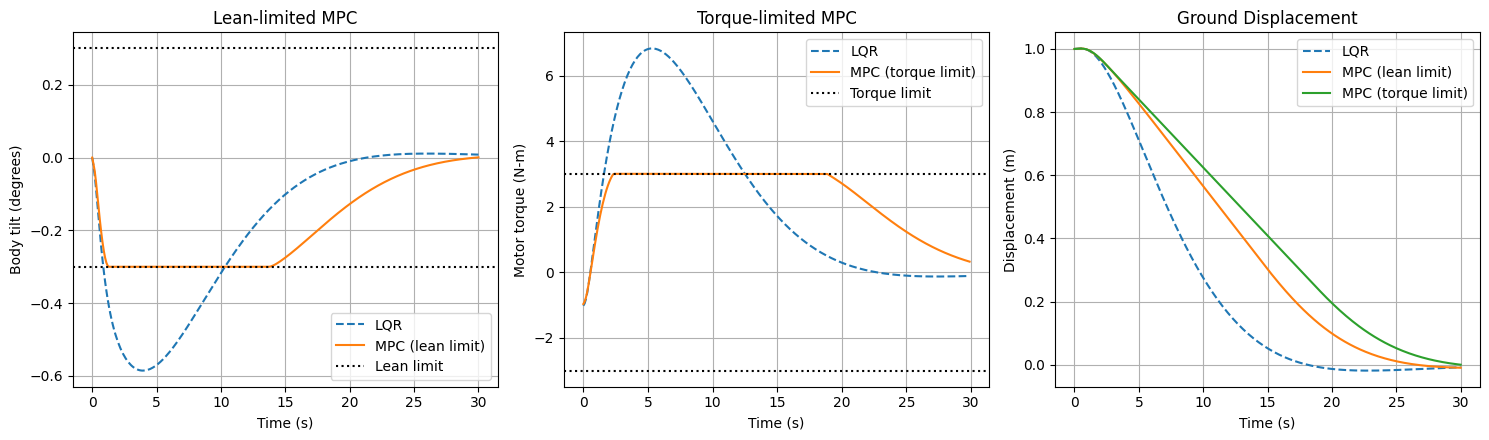

In [8]:
lean_limit = 0.3 * np.pi/180   # rad (illustrative)
torque_limit = 3               # N-m (illustrative)
T_con = 300

X_l, U_l = simulate_lqr(K, initial_state, T_con)
X_lean, U_lean, s_lean = run_mpc(initial_state, T_con, lean_limit=lean_limit)
X_tau, U_tau, s_tau = run_mpc(initial_state, T_con, torque_limit=torque_limit)
Time_con = np.linspace(0, T_con*dt, T_con+1)

print('Peak lean (deg):   LQR %.3f | MPC lean-limited %.3f | limit %.2f'
      % (np.degrees(np.max(np.abs(X_l[:,0] + X_l[:,1]))), np.degrees(np.max(np.abs(X_lean[:,0] + X_lean[:,1]))), np.degrees(lean_limit)))
print('Peak torque (N-m): LQR %.3f | MPC torque-limited %.3f | limit %.2f'
      % (np.max(np.abs(motor_torque(X_l, U_l))), np.max(np.abs(motor_torque(X_tau, U_tau))), torque_limit))
print('Settling time (s): LQR %.1f | lean-limited %.1f | torque-limited %.1f'
      % (settling_time(X_l, 1.0), settling_time(X_lean, 1.0), settling_time(X_tau, 1.0)))
print('Largest planned violation (fraction of limit): lean %.1e | torque %.1e' % (s_lean, s_tau))

plt.figure(figsize=(15, 4.5))
plt.subplot(1, 3, 1)
plt.plot(Time_con, np.degrees(X_l[:,0] + X_l[:,1]), '--', label = 'LQR')
plt.plot(Time_con, np.degrees(X_lean[:,0] + X_lean[:,1]), label = 'MPC (lean limit)')
plt.axhline(np.degrees(lean_limit), color = 'k', linestyle = ':')
plt.axhline(-np.degrees(lean_limit), color = 'k', linestyle = ':', label = 'Lean limit')
plt.xlabel('Time (s)')
plt.ylabel('Body tilt (degrees)')
plt.title('Lean-limited MPC')
plt.legend()
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(Time_con[:-1], motor_torque(X_l, U_l), '--', label = 'LQR')
plt.plot(Time_con[:-1], motor_torque(X_tau, U_tau), label = 'MPC (torque limit)')
plt.axhline(torque_limit, color = 'k', linestyle = ':')
plt.axhline(-torque_limit, color = 'k', linestyle = ':', label = 'Torque limit')
plt.xlabel('Time (s)')
plt.ylabel('Motor torque (N-m)')
plt.title('Torque-limited MPC')
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(Time_con, X_l[:,0] * r_b, '--', label = 'LQR')
plt.plot(Time_con, X_lean[:,0] * r_b, label = 'MPC (lean limit)')
plt.plot(Time_con, X_tau[:,0] * r_b, label = 'MPC (torque limit)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Ground Displacement')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()